In [15]:
import pandas as pd

data = pd.read_csv("TimeSeries_TotalSolarGen_and_Load_IT_2016.csv")

In [16]:
data.head()

,utc_timestamp,IT_load_new,IT_solar_generation
0,2016-01-01T00:00:00Z,21665.0,1
1,2016-01-01T01:00:00Z,20260.0,0
2,2016-01-01T02:00:00Z,19056.0,0
3,2016-01-01T03:00:00Z,18407.0,0
4,2016-01-01T04:00:00Z,18425.0,0


In [18]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 8784 entries, 0 to 8783
Data columns (total 3 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   utc_timestamp        8784 non-null   str    
 1   IT_load_new          8712 non-null   float64
 2   IT_solar_generation  8784 non-null   int64  
dtypes: float64(1), int64(1), str(1)
memory usage: 206.0 KB


72 null values found in IT_load_new

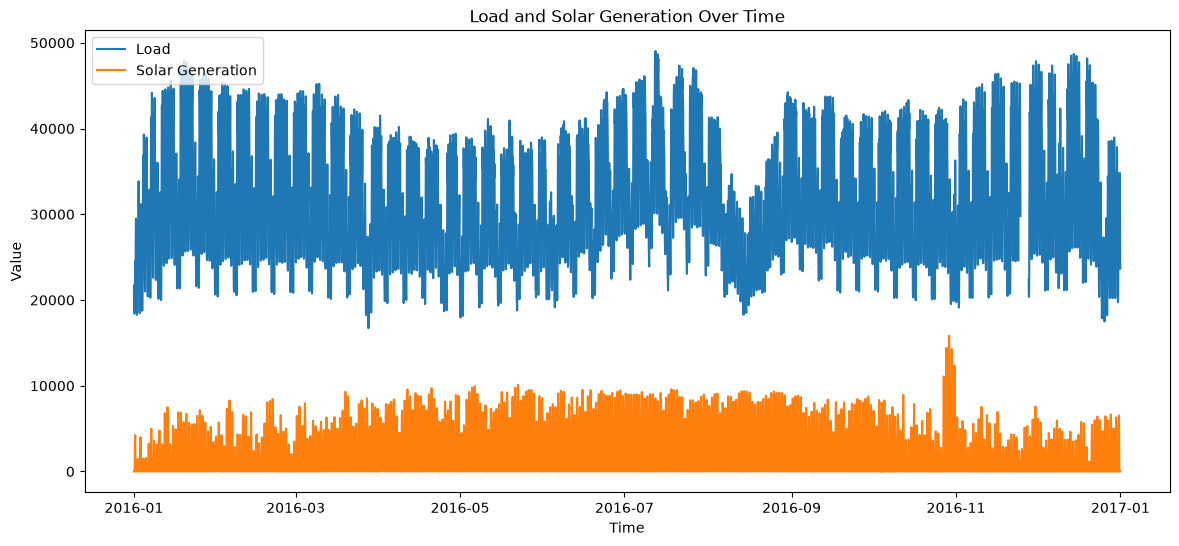

In [19]:
import matplotlib.pyplot as plt

data['utc_timestamp'] = pd.to_datetime(data['utc_timestamp'])

plt.figure(figsize=(14, 6))
plt.plot(data['utc_timestamp'], data['IT_load_new'], label='Load')
plt.plot(data['utc_timestamp'], data['IT_solar_generation'], label='Solar Generation')
plt.xlabel('Time')
plt.ylabel('Value')
plt.title('Load and Solar Generation Over Time')
plt.legend()
plt.show()

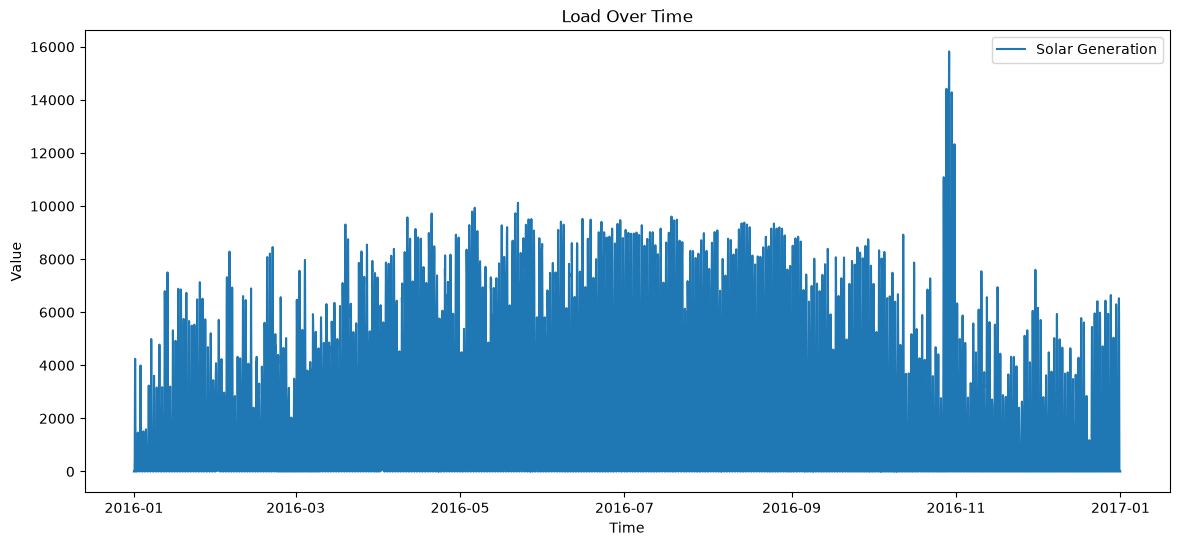

In [21]:
plt.figure(figsize=(14, 6))
plt.plot(data['utc_timestamp'], data['IT_solar_generation'], label='Solar Generation')
plt.xlabel('Time')
plt.ylabel('Value')
plt.title('Load Over Time')
plt.legend()
plt.show()

Plot shows both the load and solar generation over time for the year 2016. The load appears to have a cyclical pattern with peaks and valleys, possibly corresponding to daily patterns of electricity use.

The solar generation also shows a clear pattern, with generation during the day and no generation at night (as expected). The amount of solar generation also appears to fluctuate throughtout the year, likely due to seasonal changes in sunlight.

Next is Time series analysis and forecasting with ARIMA, before moving to that checking for stationary in our time series data. Stationarity is a property of time series data that implies the mean, variance and autocorrelation structures do not change over time. So many time series models, including ARIMA, requires the data to be stationary.

Now performing an Augmented Dickey-Fuller (ADF) test to check the stationary of the time series. The null hypothesis of the ADF test is that the time series is non-stationary. So, if the p-value of the test is less than 0.05 i.e the significance level, then we reject the null hypothesis and infer that the time series is indeed stationary.

**Handling missing values**

In [22]:
data.isnull().sum()

utc_timestamp           0
IT_load_new            72
IT_solar_generation     0
dtype: int64

In [24]:
data['IT_load_new'] = data['IT_load_new'].ffill()

In [25]:
data.isnull().sum()

utc_timestamp          0
IT_load_new            0
IT_solar_generation    0
dtype: int64

In [36]:
print("ADF Test for Load i.e 'IT_load_new' after filling missing values:")
adf_test(data['IT_load_new'])
print("\nADF Test for Solar Generation i.e 'IT_solar_generation' after filling missing values:")
adf_test(data['IT_solar_generation'])

ADF Test for Load i.e 'IT_load_new' after filling missing values:
Test Statistic                -1.197390e+01
p-value                        3.841445e-22
#Lags Used                     3.700000e+01
Number of Observations Used    8.746000e+03
Critical Value (1%)           -3.431098e+00
Critical Value (5%)           -2.861871e+00
Critical Value (10%)          -2.566946e+00
dtype: float64

ADF Test for Solar Generation i.e 'IT_solar_generation' after filling missing values:
Test Statistic                -5.741335e+00
p-value                        6.265438e-07
#Lags Used                     3.600000e+01
Number of Observations Used    8.747000e+03
Critical Value (1%)           -3.431098e+00
Critical Value (5%)           -2.861870e+00
Critical Value (10%)          -2.566946e+00
dtype: float64


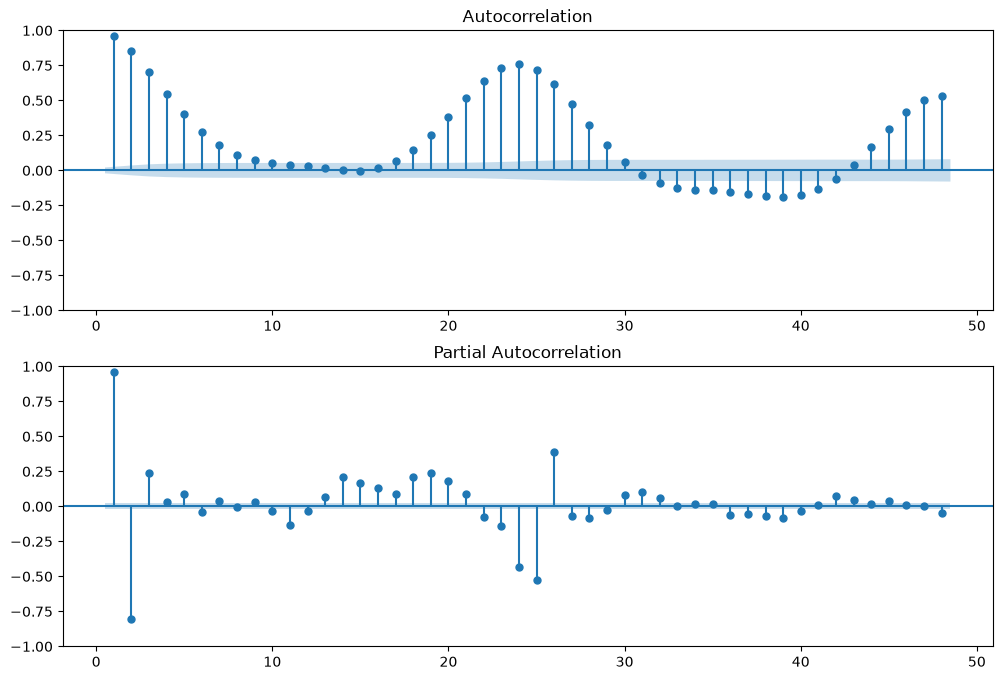

In [39]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))
plot_acf(data['IT_load_new'], lags=48, zero=False, ax=ax1)
plot_pacf(data['IT_load_new'], lags=48,zero=False, ax=ax2)
plt.show()

From the ACF plot, we see a gradual decrease, and from the PACF plot, there is a sharp drop after lag 2. So we can take p=2 and q=2 as our model's parameters.

Now fitting the ARIMA model to our IT_load_new time series. We will use the first 80% of the data for training and the last 20% for testing.

In [ ]:
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error
from math import sqrt

Taking d = {0, 1, 2}

In [58]:
train_size = int(len(data['IT_load_new'])*0.8)
train, test = data['IT_load_new'][:train_size], data['IT_load_new'][train_size:]

#taking d=0
model = ARIMA(train, order=(2,0,2))
model_fit = model.fit()

predictions = model_fit.predict(start=len(train), end=len(train) + len(test) - 1)

rmse = sqrt(mean_squared_error(test, predictions))
rmse

7714.952134844102

In [59]:
#taking d=1
model2 = ARIMA(train, order=(2,1,2))
model_fit2 = model2.fit()

predictions2 = model_fit2.predict(start=len(train), end=len(train) + len(test) - 1)

rmse2 = sqrt(mean_squared_error(test, predictions2))
rmse2

7993.849454913083

In [60]:
#taking d=2
model3 = ARIMA(train, order=(2,2,2))
model_fit3 = model3.fit()

predictions3 = model_fit3.predict(start=len(train), end=len(train) + len(test) - 1)

rmse3 = sqrt(mean_squared_error(test, predictions3))
rmse3

D:\anaconda__\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
D:\anaconda__\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
D:\anaconda__\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


9265.161632555162

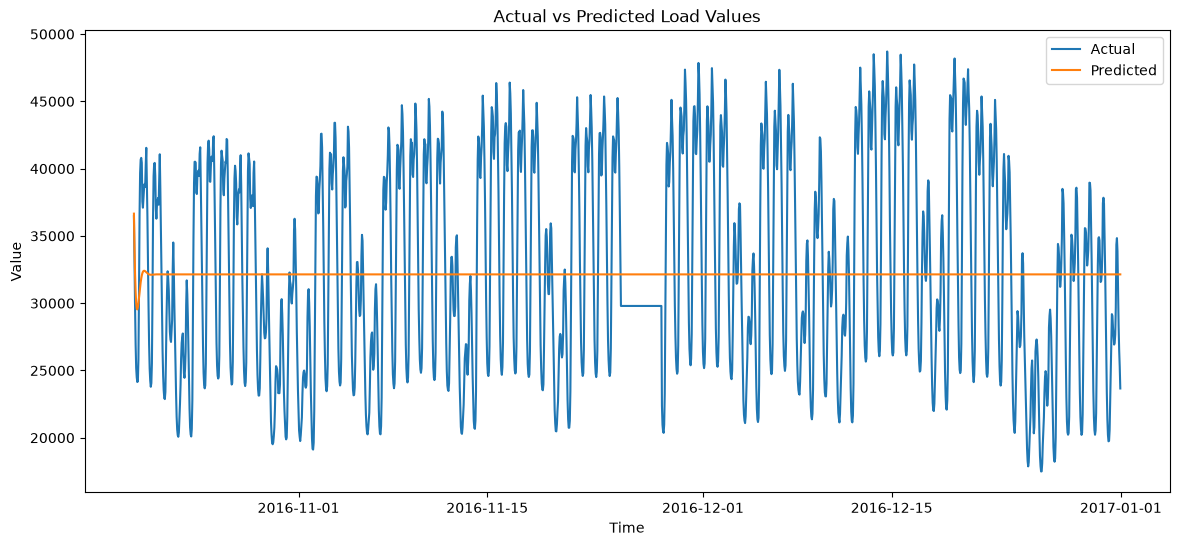

In [50]:
plt.figure(figsize=(14, 6))
plt.plot(data['utc_timestamp'][train_size:], test, label='Actual')
plt.plot(data['utc_timestamp'][train_size:], predictions, label='Predicted')
plt.xlabel('Time')
plt.ylabel('Value')
plt.title('Actual vs Predicted Load Values')
plt.legend()
plt.show()

The plot shows the actual versus the predicted load values for the test set. While the ARIMA model seems to capture the general pattern and structure of the time series data, there are still some differences between the actual and predicted values.

This inconsistency could be due to various factors such as inherent randomness in the data or other reasons, or simply the limitations of the ARIMA model. More complex models or additional data preprocessing might improve the results.

Now repeating the same process for IT_solar_generation time series data. Starting with ACF and PACF plots t determine the parameters of the model.

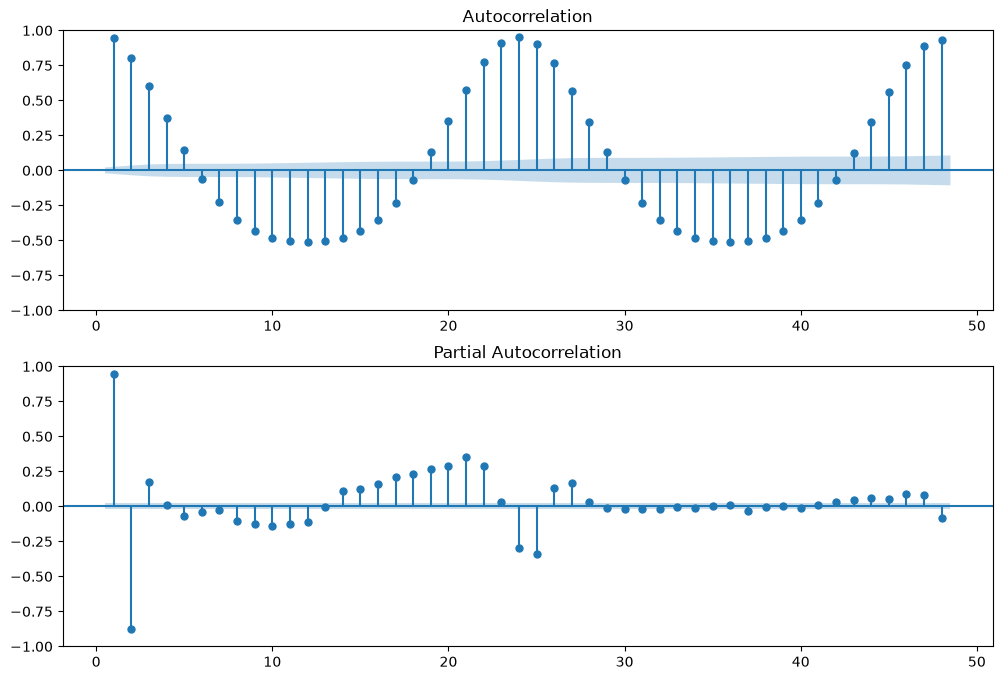

In [51]:
#Plotting ACF and PACF for IT_solar_generation

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))
plot_acf(data['IT_solar_generation'], lags=48, zero=False, ax=ax1)
plot_pacf(data['IT_solar_generation'], lags=48,zero=False, ax=ax2)
plt.show()

In [52]:
train_size = int(len(data['IT_solar_generation'])*0.8)
train, test = data['IT_solar_generation'][:train_size], data['IT_solar_generation'][train_size:]

In [54]:
model_sg = ARIMA(train, order=(2,0,2))
model_fit_sg = model.fit()

predictions_sg = model_fit_sg.predict(start=len(train), end=len(train) + len(test) - 1)

rmse = sqrt(mean_squared_error(test, predictions_sg))
rmse

2486.150711102439

In [55]:
model2_sg = ARIMA(train, order=(2,1,2))
model_fit2_sg = model2_sg.fit()

predictions2_sg = model_fit2_sg.predict(start=len(train), end=len(train) + len(test) - 1)

rmse2 = sqrt(mean_squared_error(test, predictions2_sg))
rmse2

2364.522662837661

In [56]:
model3_sg = ARIMA(train, order=(2,2,2))
model_fit3_sg = model3.fit()

predictions3_sg = model_fit3_sg.predict(start=len(train), end=len(train) + len(test) - 1)

rmse3 = sqrt(mean_squared_error(test, predictions3_sg))
rmse3

D:\anaconda__\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
D:\anaconda__\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
D:\anaconda__\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


36514.77811789536

RMSE for the model ARIMA on IT_solar_generation is apporoximately 2364 (with p=2, d=2 & q=2). As with the IT_load_new model, this RMSE value can be used as a measure of how accurately the model predicts the response.

Plotting actual values and forecasted values to visualize how well our model is performing.

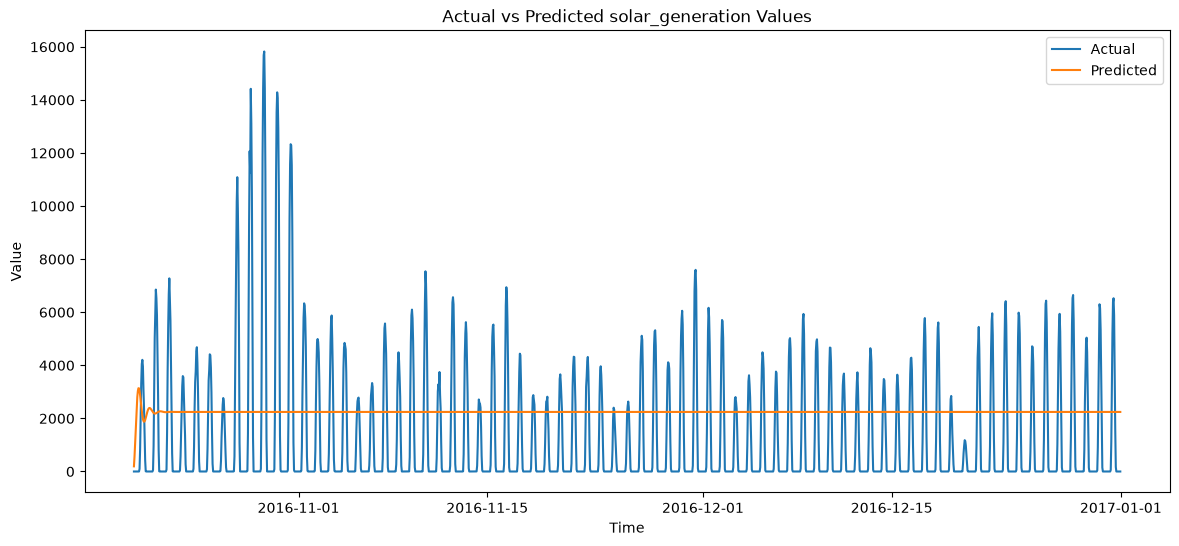

In [57]:
plt.figure(figsize=(14, 6))
plt.plot(data['utc_timestamp'][train_size:], test, label='Actual')
plt.plot(data['utc_timestamp'][train_size:], predictions, label='Predicted')
plt.xlabel('Time')
plt.ylabel('Value')
plt.title('Actual vs Predicted solar_generation Values')
plt.legend()
plt.show()

Plot shows the actual versus predicted solar generation values for the test set. As with the load model, the ARIMA model seems to capture the general pattern of the time series data.